# CO5420 Air Pollution Forecasting

## 04 — GRU Experiment and Robustness

## tl;dr

The initial GRU achieved validation RMSE `16.0906` and local-test
RMSE `27.4224`. A controlled 24-hour all-feature configuration was
then evaluated with seeds 42, 123, and 2026, producing validation
RMSE `16.1378 ± 0.1631` and local-test RMSE
`27.1180 ± 0.3287`. The GRU is reasonably stable but does not beat
the LSTM or feedforward model.

## Context & Methods

GRU architecture:

```text
Input(24, 43)
→ GRU(64)
→ Layer normalisation
→ Dropout(0.20)
→ Dense(32, ReLU)
→ Dropout(0.10)
→ Dense(1, Linear)
```

The architecture, optimiser, split, stopping policy, and capacity
match the LSTM experiment as closely as possible.

### Key Assumptions

- The single-seed comparison is a controlled architecture test.
- Multi-seed results are summarised using the mean and sample
  standard deviation; the best seed is not treated as a new
  hyperparameter.
- Local-test results are reported only after the configuration was
  selected using validation.

## Data

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Metrics directory exists: {METRICS_DIR.exists()}")

Project root: /mnt/c/Users/wijer/Documents/GitHub/co-5420-air-pollution
Metrics directory exists: True


In [2]:
recurrent_metrics = pd.read_csv(
    METRICS_DIR / "recurrent_metrics.csv"
)
gru_history = pd.read_csv(
    METRICS_DIR / "gru_training_history.csv"
)
ablation_results = pd.read_csv(
    METRICS_DIR / "temporal_ablation_results.csv"
)

initial_gru = recurrent_metrics.loc[
    recurrent_metrics["model"] == "gru"
].sort_values("split")

selected_runs = (
    ablation_results.loc[
        (ablation_results["model"] == "gru")
        & (ablation_results["window_size"] == 24)
        & (
            ablation_results["feature_set"]
            == "all_features"
        )
    ]
    .sort_values("seed")
    .reset_index(drop=True)
)

assert selected_runs["seed"].tolist() == [42, 123, 2026]
display(initial_gru)

,model,split,samples,epochs_trained,best_epoch,parameters,training_seconds,rmse,mae,r2
0,gru,local_test,25891,36,28,23169,166.1698,27.4224,11.8377,0.9424
1,gru,validation,25458,36,28,23169,166.1698,16.0906,8.4478,0.9662


## Results

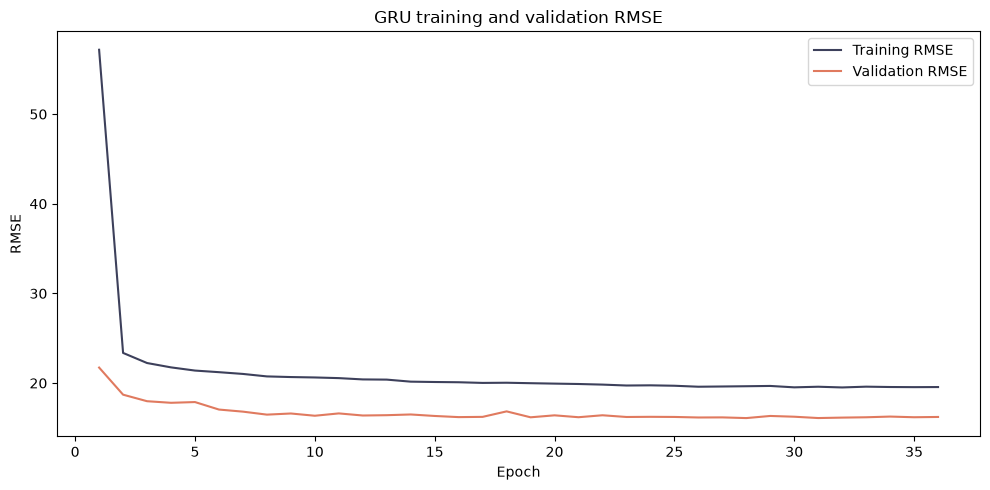

In [3]:
axis = gru_history.plot(
    x="epoch",
    y=["rmse", "val_rmse"],
    figsize=(10, 5),
    color=["#3D405B", "#E07A5F"],
)
axis.set_title("GRU training and validation RMSE")
axis.set_xlabel("Epoch")
axis.set_ylabel("RMSE")
axis.legend(["Training RMSE", "Validation RMSE"])
plt.tight_layout()
plt.show()

### Three-seed robustness

In [4]:
seed_table = selected_runs[
    [
        "seed",
        "best_epoch",
        "training_seconds",
        "validation_rmse",
        "validation_mae",
        "validation_r2",
        "local_test_rmse",
        "local_test_mae",
        "local_test_r2",
    ]
]
display(seed_table)

robustness = pd.Series(
    {
        "runs": len(selected_runs),
        "validation_rmse_mean": (
            selected_runs["validation_rmse"].mean()
        ),
        "validation_rmse_sample_sd": (
            selected_runs["validation_rmse"].std(ddof=1)
        ),
        "local_test_rmse_mean": (
            selected_runs["local_test_rmse"].mean()
        ),
        "local_test_rmse_sample_sd": (
            selected_runs["local_test_rmse"].std(ddof=1)
        ),
        "local_test_mae_mean": (
            selected_runs["local_test_mae"].mean()
        ),
    },
    name="value",
)
display(robustness.to_frame())

,seed,best_epoch,training_seconds,validation_rmse,validation_mae,validation_r2,local_test_rmse,local_test_mae,local_test_r2
0,42,19,140.7417,16.1782,8.5014,0.9658,27.2517,11.8266,0.9431
1,123,18,140.7833,15.9583,8.4340,0.9667,26.7436,11.7825,0.9452
2,2026,11,102.5317,16.2768,8.4505,0.9654,27.3588,11.8290,0.9427


,value
runs,3.0000
validation_rmse_mean,16.1378
validation_rmse_sample_sd,0.1631
local_test_rmse_mean,27.1180
local_test_rmse_sample_sd,0.3287
local_test_mae_mean,11.8127


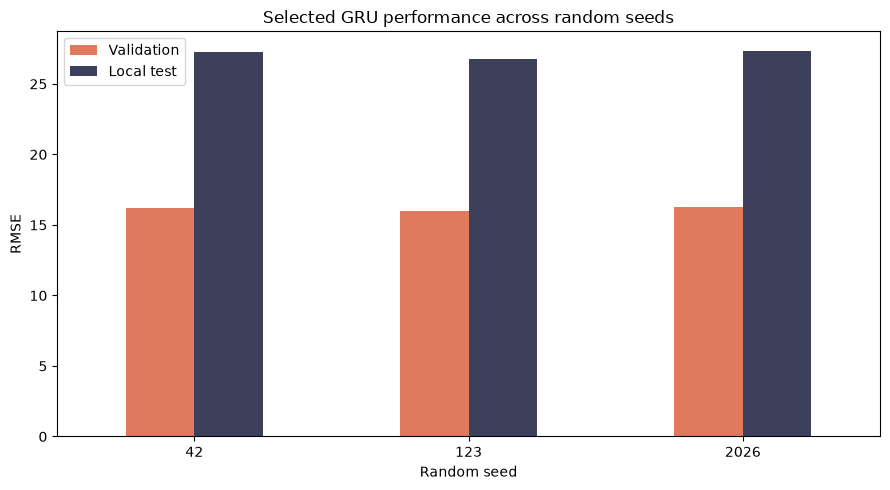

In [5]:
plot_data = selected_runs.set_index("seed")[
    ["validation_rmse", "local_test_rmse"]
]
axis = plot_data.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#E07A5F", "#3D405B"],
)
axis.set_title("Selected GRU performance across random seeds")
axis.set_xlabel("Random seed")
axis.set_ylabel("RMSE")
axis.tick_params(axis="x", rotation=0)
axis.legend(["Validation", "Local test"])
plt.tight_layout()
plt.show()

### Recurrent architecture comparison

In [6]:
recurrent_comparison = recurrent_metrics.pivot(
    index="model",
    columns="split",
    values=["rmse", "mae"],
).sort_values(("rmse", "validation"))
display(recurrent_comparison)

rmse                   mae           
split local_test validation local_test validation
model                                            
lstm     25.9367    15.6505    11.4252     8.3936
gru      27.4224    16.0906    11.8377     8.4478

## Takeaways

- GRU performance varies modestly across random seeds; the
  validation RMSE sample standard deviation is about 1% of its
  mean.
- Seed 123 is the strongest run, but it is not selected
  post-hoc as a new configuration.
- The LSTM remains stronger than the GRU under the equivalent
  single-seed comparison.
- GRU experiments remain valuable because they establish temporal
  architecture, window-length, feature-ablation, and robustness
  evidence.

Reproduce the selected multi-seed runs:

```bash
conda activate co5420-air-gpu
python -m scripts.run_temporal_ablation \
  --model gru \
  --window-sizes 24 \
  --feature-sets all_features \
  --seeds 42 123 2026 \
  --batch-size 512
```